In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('tracking/tracking_utils')

from tracking.tracking_utils.model import GNNTrackingModel
import torch


In [ ]:
config = {
    'optimizer': 'radam',
    'learning_rate': 5e-4,
    'weight_decay': 0,
    'decay': 0.99,
    'scheduler': 'reduce_on_plateau',
    'max_epochs': 50,
    'batch_size': 6,
    'n_layers': 1,
    'num_workers': 8,
    'clipnorm': 1e-3,
    'step_size': 5,
    'crop_mode': 'fixed',
    'patience': 5,
    'log_and_save': True,
    'enable_early_stopping': True,
    'crop_size': 16,
    'attention': False,
    'truncate_dataset': None,
    'loss': 'wcce'
}

model = GNNTrackingModel(
                            graph_layer='gat', 
                            data_format='channels_last',
                            encoder_dim=64,
                            n_layers=config['n_layers'],
                            crop_size=config['crop_size'],
                            attention=config['attention']
                            )

checkpoint = torch.load('checkpoints/20251123-063939/best_model.pt')
model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device('cuda:2')
model = model.to(device)

In [ ]:
import zarr

from tracking.tracking_utils.loader import create_trk_dataloaders

_, _, test_loader = create_trk_dataloaders(
    test_path='data/DynamicNuclearNet-tracking-v1_0/test.zarr',
    batch_size=config['batch_size'],
    distance_threshold=64,
    augment=True,
    crop_mode=config['crop_mode'],
    num_workers=config['num_workers'],
    crop_size=config['crop_size'],
    truncate_dataset = config['truncate_dataset'],
    mode='inference'
    )





Loading data/DynamicNuclearNet-tracking-v1_0/test.zarr...


100%|██████████| 12/12 [00:25<00:00,  2.14s/it]

  X shape: (12, 71, 584, 600, 1)
  y shape: (12, 71, 584, 600, 1)
  Lineages: 12
  Created 533 samples


In [10]:
import numpy as np
import matplotlib.pyplot as plt

test_iter = iter(test_loader)
data = next(test_iter)

embeddings, centroids = model.get_embeddings(data['appearances'].to(device), data['morphologies'].to(device), data['centroids'].to(device), data['adj_matrices'].to(device))



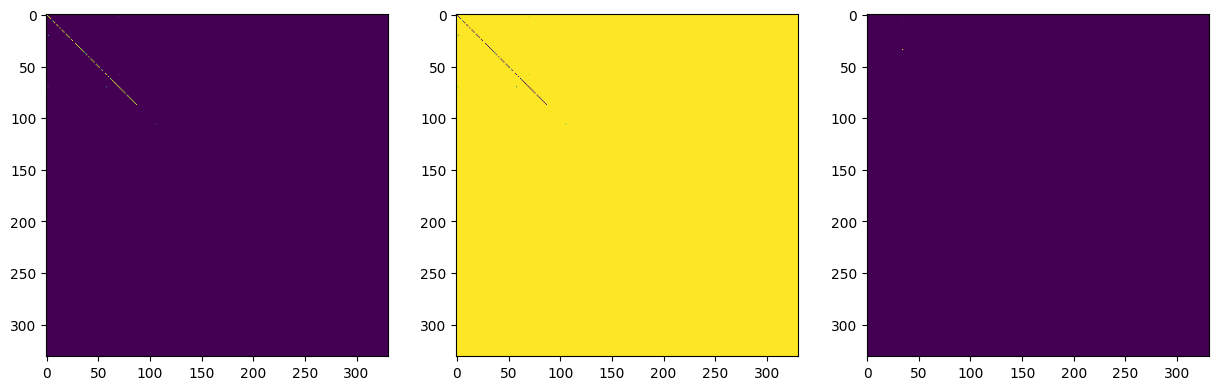

In [27]:
frame = 6

output = model.inference_forward(embeddings[:,frame:frame+1], 
                        centroids[:,frame:frame+1], 
                        embeddings[:,frame+1:frame+2], 
                        centroids[:,frame+1:frame+2]).cpu()



fig, ax = plt.subplots(1,3, figsize=(15,5))
for i, axis in enumerate(ax.ravel()):
    axis.imshow(output[2,0,...,i])

plt.show()


# plt.figure()
# fig, ax = plt.subplots(1,3)
# for i, axis in enumerate(ax.ravel()):
#     axis.imshow(labels[0,frame,...,i])

# plt.show()